## Hồi quy tuyến tính (Linear Regression)


Mục tiêu là đoán cân nặng dựa vào chiều cao của một người.

## 1. Mô hình Linear Regression
$$
y \approx f(x) = \hat{y}  
$$
$$
y = w_1x_1 + w_2x_2 + w_3x_3 + ... + w_0
$$
Trong đó $w_1, w_2, w_3, w_0$ là các hằng số, $w_0$ còn được gọi là bias. Mối quan hệ y ≈ f(x) bên trên là một mối quan hệ tuyến tính (linear).

Lưu ý 1:

Trong bài toán hồi quy tuyến tính, ta phân biệt hai giá trị:

- \(y\): giá trị thực tế của biến đầu ra, được lấy từ dữ liệu trong tập huấn luyện (training data).
- \($\hat{y}$): giá trị dự đoán bởi mô hình Linear Regression.

Mục tiêu của mô hình là tìm các tham số sao cho giá trị dự đoán \($\hat{y}$) càng gần với giá trị thực \(y\) càng tốt, tức là sai số giữa hai giá trị này phải nhỏ.


Lưu ý 2:

Từ Linear có nghĩa là tuyến tính. Hình dạng của mô hình tuyến tính phụ thuộc vào số chiều của dữ liệu:

- Trong không gian 1 chiều, mô hình tuyến tính biểu diễn bằng một đường thẳng.
- Trong không gian 2 chiều, nó tương ứng với một mặt phẳng.
- Khi số chiều lớn hơn (3 chiều trở lên), ta không thể trực quan hóa được nữa. Khi đó, mô hình tuyến tính được gọi chung là siêu phẳng (hyperplane).

Linear Regression thực chất là việc tìm một siêu phẳng tốt nhất để xấp xỉ mối quan hệ giữa các biến đầu vào và biến đầu ra.

## 2 Dạng tổng quát

Trong mô hình hồi quy tuyến tính nhiều biến, ta gom các hệ số vào một vector.

Gọi vector trọng số:

$$
\mathbf{w} =
\begin{bmatrix}
w_1 \\
w_2 \\
w_3 \\
w_0
\end{bmatrix}
$$

là vector cột chứa các hệ số cần tìm.

Ta định nghĩa vector đầu vào mở rộng:

$$
\bar{x} = [1, x_1, x_2, x_3]
$$

Khi đó mô hình dự đoán được viết:

$$
\hat{y} = \bar{x}\mathbf{w}
$$


### Sai số dự đoán

Sai số giữa giá trị thực và dự đoán:

$$
e = y - \hat{y}
$$

Để đo mức sai lệch ta dùng bình phương sai số:

$$
\frac{1}{2}e^2 = (y - \hat{y})^2
$$

Thay $\hat{y} = \bar{x}\mathbf{w}$ ta có:

$$
(y - \bar{x}\mathbf{w})^2
$$


### Hàm mất mát

Giả sử tập dữ liệu gồm $N$ mẫu:

$$
(x_1,y_1),(x_2,y_2),...,(x_N,y_N)
$$

Hàm mất mát được định nghĩa:

$$
L(\mathbf{w}) =
\frac{1}{2}
\sum_{i=1}^{N}
(y_i - \bar{x_i}\mathbf{w})^2
$$

Mục tiêu là tìm $\mathbf{w}$ sao cho hàm mất mát nhỏ nhất:

$$
\mathbf{w^*} =
\arg\min_{\mathbf{w}}
L(\mathbf{w})
$$


### Viết dưới dạng ma trận

Vector đầu ra:

$$
\mathbf{y} =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_N
\end{bmatrix}
$$

Ma trận dữ liệu:

$$
\bar{X} =
\begin{bmatrix}
\bar{x_1} \\
\bar{x_2} \\
\vdots \\
\bar{x_N}
\end{bmatrix}
$$

Hàm mất mát:

$$
L(\mathbf{w}) =
\frac{1}{2}
\| \mathbf{y} - \bar{X}\mathbf{w} \|_2^2
$$


### Tìm nghiệm

Lấy đạo hàm:

$$
\frac{\partial L(\mathbf{w})}{\partial \mathbf{w}}
=
\bar{X}^T(\bar{X}\mathbf{w} - \mathbf{y})
$$

Cho đạo hàm bằng 0:

$$
\bar{X}^T(\bar{X}\mathbf{w} - \mathbf{y}) = 0
$$

Suy ra:

$$
\bar{X}^T\bar{X}\mathbf{w} =
\bar{X}^T\mathbf{y}
$$

Nếu $\bar{X}^T\bar{X}$ khả nghịch:

$$
\mathbf{w} =
(\bar{X}^T\bar{X})^{-1}
\bar{X}^T
\mathbf{y}
$$

## 3 Ví dụ trên Python
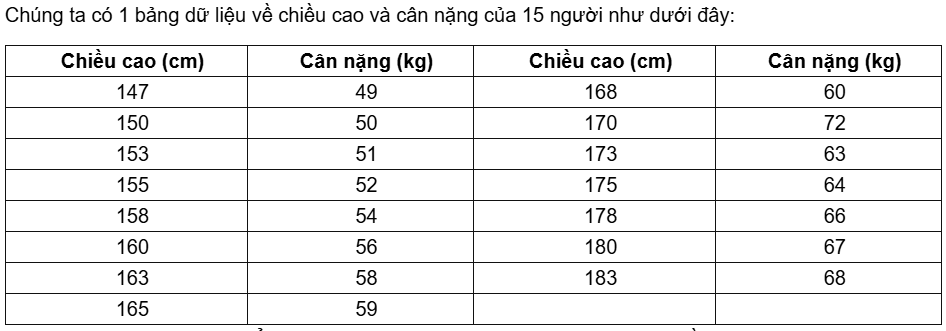

Bài toán đặt ra: dựa vào chiều cao để đoán được cân nặng của một người

##  Import thư viện

In [2]:
# Hỗ trợ cả Python 2 và Python 3.
from __future__ import division, print_function, unicode_literals
import numpy as np 
import matplotlib.pyplot as plt

## Dữ liệu và trực quan hóa dữ liệu


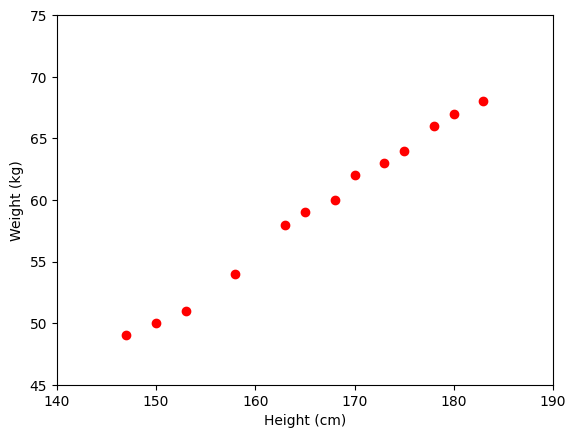

In [3]:
# chiều cao (cm)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
# cân nặng (kg)
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T
# trực quan hóa dữ liệu
plt.plot(X, y, 'ro')
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

## Theo công thức

w =  [[-33.73541021]
 [  0.55920496]]


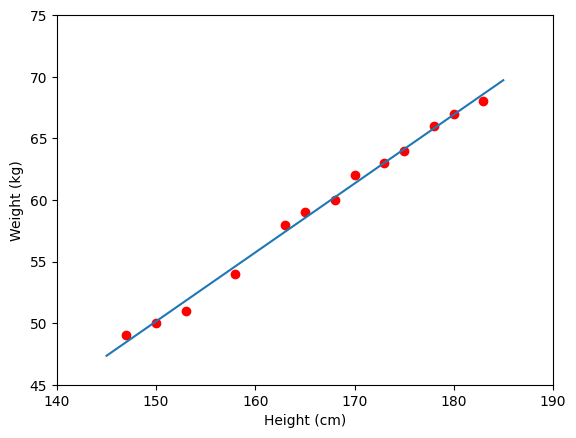

In [4]:
# Xây dựng Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

# Tính toán trọng lượng của đường khớp
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)
# Chuẩn bị dây chuyền lắp đặt
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

# Vẽ đường phù hợp
plt.plot(X.T, y.T, 'ro')     # dữ liệu
plt.plot(x0, y0)               # dòng phù hợp
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()



In [5]:
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0

print( u'Predict weight of person with height 155 cm: %.2f (kg), real number: 52 (kg)'  %(y1) )
print( u'Predict weight of person with height 160 cm: %.2f (kg), real number: 56 (kg)'  %(y2) )

Predict weight of person with height 155 cm: 52.94 (kg), real number: 52 (kg)
Predict weight of person with height 160 cm: 55.74 (kg), real number: 56 (kg)


## The scikit-learn thư viện

In [8]:
from sklearn import datasets, linear_model

# fit the model by Linear Regression
regr = linear_model.LinearRegression(fit_intercept=False) # fit_intercept = False for calculating the bias
regr.fit(Xbar, y)

# Compare two results
print( 'Solution found by scikit-learn  : ', regr.coef_ )
print( 'Solution found by (5): ', w.T)

Solution found by scikit-learn  :  [[-33.73541021   0.55920496]]
Solution found by (5):  [[-33.73541021   0.55920496]]
